In [1]:
!pip install "numpy==2.0.2" pennylane pennylane-qiskit qiskit qiskit-aer qiskit-ibm-runtime mitiq


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 45.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of mitiq to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of mitiq to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/9

In [2]:
"""
evaluation_schemes.py

"""

import numpy as np
from sklearn.metrics import f1_score, hamming_loss, classification_report



def exact_match_scores(gold: np.ndarray, preds: np.ndarray) -> dict:
    
    assert gold.shape == preds.shape, "gold and preds must have the same shape"

    # Row-wise equality: True only when ALL labels in a row match
    row_matches = np.all(gold == preds, axis=1)          # (N,) bool
    emr = float(row_matches.mean())                      # Exact Match Ratio

    # For a strict binary decision (match vs. no-match):
    #   TP = matched samples, FP = 0, FN = 0  →  P = R = F1 = EMR
    return {
        "precision"         : emr,
        "recall"            : emr,
        "f1"                : emr,
        "exact_match_ratio" : emr,
        "num_exact_matches" : int(row_matches.sum()),
    }



def _instance_prf(gold_row: np.ndarray, pred_row: np.ndarray):
    
    gold_set = set(np.where(gold_row == 1)[0])
    pred_set = set(np.where(pred_row == 1)[0])

    # Both empty → perfect prediction
    if len(gold_set) == 0 and len(pred_set) == 0:
        return 1.0, 1.0, 1.0

    # One empty, the other not → zero overlap
    if len(gold_set) == 0 or len(pred_set) == 0:
        return 0.0, 0.0, 0.0

    overlap = len(gold_set & pred_set)
    precision = overlap / len(pred_set)
    recall    = overlap / len(gold_set)
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    return precision, recall, f1


def partial_match_scores(gold: np.ndarray, preds: np.ndarray) -> dict:
    
    assert gold.shape == preds.shape

    precisions, recalls, f1s = [], [], []
    for g_row, p_row in zip(gold, preds):
        p, r, f = _instance_prf(g_row, p_row)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)

    return {
        "precision" : float(np.mean(precisions)),
        "recall"    : float(np.mean(recalls)),
        "f1"        : float(np.mean(f1s)),
    }

def evaluate_all_schemes(
    gold: np.ndarray,
    preds: np.ndarray,
    label_names: list[str] | None = None,
    verbose: bool = True,
) -> dict:
    

    # ── Scheme 1 : Per-label sklearn metrics ──────────────────────────────────
    scheme1 = {
        "macro_f1"    : f1_score(gold, preds, average="macro",    zero_division=0),
        "micro_f1"    : f1_score(gold, preds, average="micro",    zero_division=0),
        "weighted_f1" : f1_score(gold, preds, average="weighted", zero_division=0),
        "hamming_loss": hamming_loss(gold, preds),
    }

    # ── Scheme 2 : Exact match ────────────────────────────────────────────────
    scheme2 = exact_match_scores(gold, preds)

    # ── Scheme 3 : Partial match ──────────────────────────────────────────────
    scheme3 = partial_match_scores(gold, preds)

    results = {"scheme1": scheme1, "scheme2": scheme2, "scheme3": scheme3}

    if verbose:
        _print_report(results, gold, preds, label_names)

    return results


def _print_report(results, gold, preds, label_names):
    sep = "=" * 62

    print(sep)
    print("  SCHEME 1 – Per-label sklearn metrics  (existing baseline)")
    print(sep)
    s1 = results["scheme1"]
    print(f"  Macro  F1      : {s1['macro_f1']:.4f}")
    print(f"  Micro  F1      : {s1['micro_f1']:.4f}")
    print(f"  Weighted F1    : {s1['weighted_f1']:.4f}")
    print(f"  Hamming Loss   : {s1['hamming_loss']:.4f}")
    if label_names:
        print("\n  Per-label classification report:")
        print(
            classification_report(
                gold, preds,
                target_names=label_names,
                digits=4,
                zero_division=0,
            )
        )

    print(sep)
    print("  SCHEME 2 – Exact Match")
    print(sep)
    s2 = results["scheme2"]
    print(f"  Exact Match Ratio (EMR) : {s2['exact_match_ratio']:.4f}")
    print(f"  Num Exact Matches       : {s2['num_exact_matches']}")
    print(f"  Precision               : {s2['precision']:.4f}")
    print(f"  Recall                  : {s2['recall']:.4f}")
    print(f"  F1                      : {s2['f1']:.4f}")
    print("  [Note: P = R = F1 = EMR for strict exact-match scoring]")

    print(sep)
    print("  SCHEME 3 – Partial Match  (instance-level set overlap)")
    print(sep)
    s3 = results["scheme3"]
    print(f"  Precision (macro-inst.) : {s3['precision']:.4f}")
    print(f"  Recall    (macro-inst.) : {s3['recall']:.4f}")
    print(f"  F1        (macro-inst.) : {s3['f1']:.4f}")
    print(sep)



if __name__ == "__main__":
    rng = np.random.default_rng(42)

    EMOTION_COLS = ["Love", "Joy", "Surprise", "Anger", "Sadness", "Fear"]

    # Simulate gold labels and predictions
    gold  = (rng.random((50, 6)) > 0.6).astype(int)
    preds = gold.copy()

    # Flip ~15 % of bits to simulate imperfect predictions
    flip_mask = rng.random((50, 6)) < 0.15
    preds[flip_mask] = 1 - preds[flip_mask]

    # --- Manual examples from the task description ---
    print("Manual example checks")
    print("-" * 40)

    g1 = np.array([[0, 0, 1, 1, 0, 1]])
    p1 = np.array([[0, 0, 1, 1, 0, 1]])   # perfect
    g2 = np.array([[0, 0, 1, 1, 0, 1]])
    p2 = np.array([[0, 0, 1, 1, 0, 0]])   # one label off

    print("Example 1 (perfect):")
    print(f"  Exact match score  : {exact_match_scores(g1, p1)['exact_match_ratio']}")
    print(f"  Partial match F1   : {partial_match_scores(g1, p1)['f1']:.4f}")

    print("Example 2 (one label off):")
    print(f"  Exact match score  : {exact_match_scores(g2, p2)['exact_match_ratio']}")
    print(f"  Partial match F1   : {partial_match_scores(g2, p2)['f1']:.4f}")

    print("\nFull 50-sample evaluation:")
    evaluate_all_schemes(gold, preds, label_names=EMOTION_COLS, verbose=True)

Manual example checks
----------------------------------------
Example 1 (perfect):
  Exact match score  : 1.0
  Partial match F1   : 1.0000
Example 2 (one label off):
  Exact match score  : 0.0
  Partial match F1   : 0.8000

Full 50-sample evaluation:
  SCHEME 1 – Per-label sklearn metrics  (existing baseline)
  Macro  F1      : 0.8069
  Micro  F1      : 0.8097
  Weighted F1    : 0.8147
  Hamming Loss   : 0.1567

  Per-label classification report:
              precision    recall  f1-score   support

        Love     0.7826    0.8182    0.8000        22
         Joy     0.7727    0.8500    0.8095        20
    Surprise     0.5714    0.8571    0.6857        14
       Anger     0.8095    0.9444    0.8718        18
     Sadness     0.6667    0.8421    0.7442        19
        Fear     0.9524    0.9091    0.9302        22

   micro avg     0.7576    0.8696    0.8097       115
   macro avg     0.7592    0.8702    0.8069       115
weighted avg     0.7727    0.8696    0.8147       115
 samp

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, hamming_loss
)
from sklearn.utils.class_weight import compute_class_weight

from tqdm import tqdm
import pennylane as qml
import sys

In [4]:
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu_device = torch.device("cpu")

print("GPU device:", gpu_device)
print("CPU device:", cpu_device)

GPU device: cuda
CPU device: cpu


In [5]:
def set_seed(seed_value=42):
    """Set seeds for reproducibility across PyTorch, NumPy, and Python."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

In [6]:
df_tr = pd.read_csv("/kaggle/input/datasets/sayanmanik2005/kaggle/Train.csv")
df_vl = pd.read_csv("/kaggle/input/datasets/sayanmanik2005/kaggle/Val.csv")
df_te = pd.read_csv("/kaggle/input/datasets/sayanmanik2005/kaggle/Test.csv")
# Reset indices for safe iloc access in Dataset
df_tr = df_tr.reset_index(drop=True)
df_vl = df_vl.reset_index(drop=True)
df_te = df_te.reset_index(drop=True)

print("Train:", df_tr.shape, "| Valid:", df_vl.shape, "| Test:", df_te.shape)
df_tr.head()

Train: (18420, 11) | Valid: (2047, 11) | Test: (2272, 11)


,ID,Data,Love,Joy,Surprise,Anger,Sadness,Fear,Topic,Domain,is_admin
0,5454,লকাল বাস ভালো এটা থেকে,0,0,0,0,1,0,Travel,Youtube,False
1,22549,কত অভিজানই তো চলে কিন্তু ওয়াসার পানির অভিজান ক...,0,0,0,0,1,0,Politics,Youtube,False
2,7033,বিয়ের মহল ছেড়ে তিনি বিস্রাম নিতে চলে যান (৬ ...,0,0,0,1,0,0,Personal,Facebook,False
3,21114,চাচাজি তো কেবল মাকে ধর্ষণ করেছেন,0,0,0,0,1,0,Education,Facebook,False
4,23683,সত্যিকার মানুষ তারাই ভাই,0,1,0,0,0,0,Personal,Youtube,False


In [7]:
EMOTION_COLS = ['Love', 'Joy', 'Surprise', 'Anger', 'Sadness', 'Fear']
TEXT_COL     = 'Data'
NUM_LABELS   = len(EMOTION_COLS)

# Convert binary emotion columns into a single 'Label' string column
for split_name, split_df in [('Train', df_tr), ('Valid', df_vl), ('Test', df_te)]:
    if 'Label' not in split_df.columns:
        # idxmax(axis=1) picks the column name ('Love', 'Sadness', etc.) where value is 1
        split_df['Label'] = split_df[EMOTION_COLS].idxmax(axis=1)

# Validation check
for split_name, split_df in [('Train', df_tr), ('Valid', df_vl), ('Test', df_te)]:
    assert TEXT_COL in split_df.columns, f"{split_name}: missing column '{TEXT_COL}'"
    assert 'Label' in split_df.columns, f"{split_name}: missing column 'Label'"
    assert set(split_df['Label'].unique()) <= set(EMOTION_COLS), f"{split_name}: unknown labels present"

print(f"NUM_LABELS = {NUM_LABELS}  →  {EMOTION_COLS}")
print("\nTrain label distribution:")
print(df_tr['Label'].value_counts())


NUM_LABELS = 6  →  ['Love', 'Joy', 'Surprise', 'Anger', 'Sadness', 'Fear']

Train label distribution:
Label
Joy         6478
Sadness     3975
Love        3786
Anger       3295
Surprise     724
Fear         162
Name: count, dtype: int64


In [8]:
class EmoNoBaDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.data      = df
        self.tokenizer = tokenizer
        self.max_len   = max_length
        self.label2idx = {lbl: i for i, lbl in enumerate(EMOTION_COLS)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        encoding = self.tokenizer(
            str(row[TEXT_COL]),
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        label = torch.tensor(
            self.label2idx[row['Label']],
            dtype=torch.long
        )

        return (
            encoding['input_ids'].squeeze(0),       # (max_length,)
            encoding['attention_mask'].squeeze(0),  # (max_length,)
            label                                   # () long, single class index
        )

In [9]:
TEXT_MODEL   = 'ai4bharat/IndicBERTv2-MLM-only'

tokenizer    = AutoTokenizer.from_pretrained(TEXT_MODEL)
text_encoder = AutoModel.from_pretrained(TEXT_MODEL).to(gpu_device)

print("Text encoder loaded on:", next(text_encoder.parameters()).device)

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 7.75MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Text encoder loaded on: cuda:0


[tensor([0.1492], dtype=torch.float64), tensor([-0.1737], dtype=torch.float64), tensor([-0.1063], dtype=torch.float64), tensor([0.0375], dtype=torch.float64)]


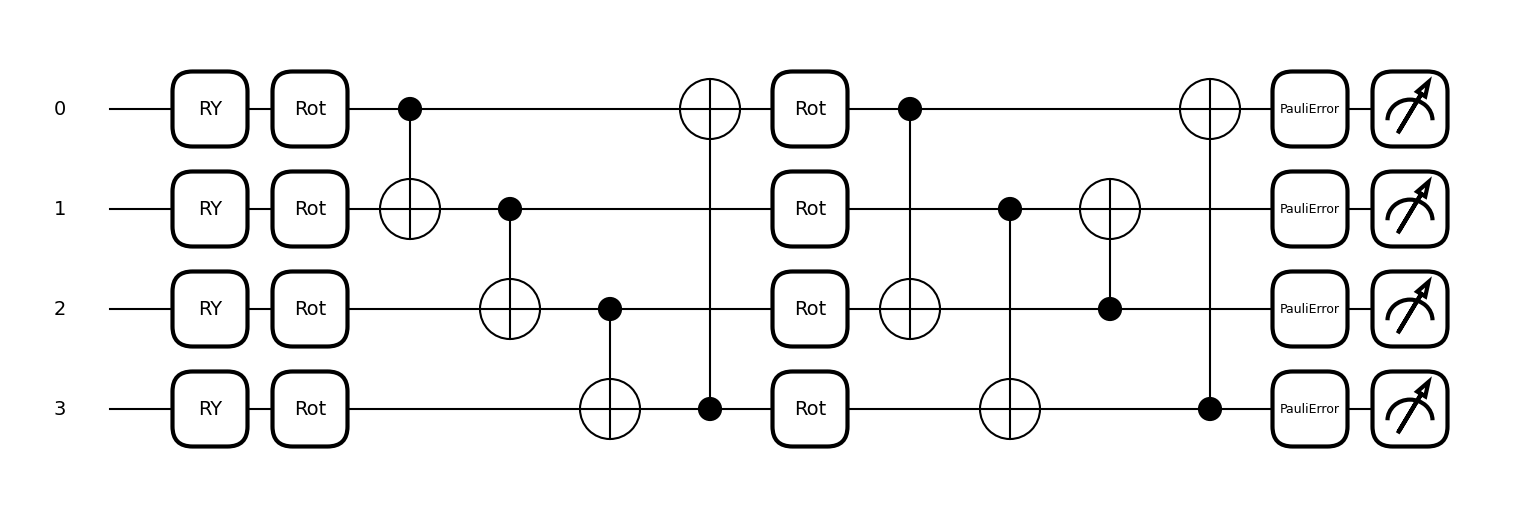

In [10]:
import pennylane as qml
import torch
import torch.nn as nn
n_qubits=4
n_qlayers=1
p_noise=0.26
dev=qml.device("default.mixed",wires=n_qubits)
@qml.qnode(dev,interface="torch",diff_method="backprop")
def vqc(inputs,weights):
    for i in range(n_qubits):
        qml.RY(inputs[:, i],wires=i)
        
        #ring entanglement
    
    for i in range(n_qubits):
        qml.Rot(weights[0][i][0],weights[0][i][1],weights[0][i][2],wires=i)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])
    qml.CNOT(wires=[3,0])
    
    #cross entanglement
    
    for i in range(n_qubits):
        qml.Rot(weights[0][i][0],weights[0][i][1],weights[0][i][2],wires=i)
    qml.CNOT(wires=[0,2])
    qml.CNOT(wires=[1,3])
    qml.CNOT(wires=[2,1])
    qml.CNOT(wires=[3,0])
    for i in range(n_qubits):
        qml.PauliError("Y", p_noise, wires=i)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    
inputs=torch.tensor([[0.5,1.0,1.5,2.0]])
weights=np.random.random((1,4,3))
print(vqc(inputs,weights))
fig,ax=qml.draw_mpl(vqc)(inputs,weights)
plt.show()

In [11]:
class QuantumBottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights=nn.Parameter(torch.randn(n_qlayers,n_qubits,3))
    def forward(self,x):
        # Pass entire batch directly to PennyLane, staying on GPU
        q_out_list = vqc(x, self.weights)
        out = torch.stack(q_out_list, dim=1)
        return out

In [12]:
class QuantumFusionLayer(nn.Module):
    def __init__(self, in_dim=128, q_dim=4):
        super().__init__()
        assert q_dim == n_qubits, "q_dim must match n_qubits"

        self.pre_q   = nn.Linear(in_dim, q_dim)
        self.quantum = QuantumBottleneck()
        self.post_q  = nn.Linear(q_dim, in_dim)

    def forward(self, x):

        x_q = torch.tanh(self.pre_q(x))
        
        q_out = self.quantum(x_q)

        q_out = q_out.float()

        return self.post_q(q_out)                     

In [13]:
class QuantumEmotionClassifier(nn.Module):
    def __init__(self, num_labels):
        super().__init__()

        self.text_encoder = text_encoder
        # Freeze text encoder to save massive time
        for param in self.text_encoder.parameters():
            param.requires_grad = False

        self.text_compressed = nn.Sequential(
            nn.Linear(768, 128),
        )

        self.quantum_fusion = QuantumFusionLayer(in_dim=128, q_dim=n_qubits)

        self.classifier = nn.Linear(128, num_labels)

    def forward(self, input_ids, attention_mask):
        text_feat = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]                       

        text_compressed = self.text_compressed(text_feat)       

        q_out  = self.quantum_fusion(text_compressed)  

        return self.classifier(F.relu(q_out))            

In [14]:
MAX_LEN    = 128
BATCH_SIZE = 8

train_dataset = EmoNoBaDataset(df_tr, tokenizer, MAX_LEN)
val_dataset   = EmoNoBaDataset(df_vl, tokenizer, MAX_LEN)
test_dataset  = EmoNoBaDataset(df_te, tokenizer, MAX_LEN)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=seed_worker, generator=g
)
val_loader   = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)
test_loader  = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    worker_init_fn=seed_worker, generator=g
)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 2303 | Val: 256 | Test: 284


In [15]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(EMOTION_COLS),
    y=df_tr['Label'].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(gpu_device)

print("Per-class weight:")
for col, w in zip(EMOTION_COLS, class_weights.cpu().numpy()):
    print(f"  {col:<12}: {w:.3f}")

Per-class weight:
  Love        : 0.811
  Joy         : 0.474
  Surprise    : 4.240
  Anger       : 0.932
  Sadness     : 0.772
  Fear        : 18.951


In [16]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds, all_gold = [], []

    for input_ids, attn_mask, labels in tqdm(dataloader, desc='Training'):
        input_ids = input_ids.to(gpu_device)
        attn_mask = attn_mask.to(gpu_device)
        labels    = labels.to(gpu_device)       # (B,) long, single class index

        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)    # (B, NUM_LABELS)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.append(preds)
        all_gold.append(labels.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_gold  = np.concatenate(all_gold)
    macro_f1  = f1_score(all_gold, all_preds, average='macro', zero_division=0)

    return total_loss / len(dataloader), macro_f1

In [17]:
def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_gold = [], []

    with torch.no_grad():
        for input_ids, attn_mask, labels in dataloader:
            input_ids = input_ids.to(gpu_device)
            attn_mask = attn_mask.to(gpu_device)
            labels    = labels.to(gpu_device)

            logits = model(input_ids, attn_mask)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            preds = logits.argmax(dim=1).cpu().numpy()          # (B,) class index
            all_preds.append(preds)
            all_gold.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)                        # (N,) class index
    all_gold  = np.concatenate(all_gold)

    # One-hot (N, NUM_LABELS) so Schemes 1-3 (per-label / exact / partial) still apply
    gold_oh = np.eye(NUM_LABELS)[all_gold]
    pred_oh = np.eye(NUM_LABELS)[all_preds]

    # ── existing metrics ──────────────────────────────────────
    base_metrics = {
        'loss'         : total_loss / len(dataloader),
        'macro_f1'     : f1_score(gold_oh, pred_oh, average='macro',    zero_division=0),
        'micro_f1'     : f1_score(gold_oh, pred_oh, average='micro',    zero_division=0),
        'weighted_f1'  : f1_score(gold_oh, pred_oh, average='weighted', zero_division=0),
        'hamming_loss' : hamming_loss(gold_oh, pred_oh),
        'preds'        : pred_oh,
        'gold'         : gold_oh,
    }

    # ── new schemes (Exact Match + Partial Match) ─────────────
    extended = evaluate_all_schemes(
        gold        = gold_oh,
        preds       = pred_oh,
        label_names = EMOTION_COLS,
        verbose     = False,         # set True to auto-print on every call
    )
    base_metrics['exact_match']   = extended['scheme2']
    base_metrics['partial_match'] = extended['scheme3']

    return base_metrics

In [18]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_state = None

    def step(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = {
                k: v.detach().cpu() for k, v in model.state_dict().items()
            }
            return False   # do NOT stop
        else:
            self.counter += 1
            return self.counter >= self.patience

    def restore(self, model):
        model.load_state_dict(self.best_state)

In [19]:
model = QuantumEmotionClassifier(num_labels=NUM_LABELS).to(gpu_device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay = 0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6,
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

early_stopping = EarlyStopping(patience=5)

print("Model on:", next(model.parameters()).device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

Model on: cuda:0
Total params: 278,141,718 | Trainable: 100,374


In [20]:
NUM_EPOCHS = 25

train_loss_arr = []
val_loss_arr   = []
val_f1_arr     = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, criterion)
    val_metrics          = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_f1   = val_metrics['macro_f1']

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Macro-F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Macro-F1: {val_f1:.4f} | "
        f"Val Micro-F1: {val_metrics['micro_f1']:.4f} | "
    )

    train_loss_arr.append(train_loss)
    val_loss_arr.append(val_loss)
    val_f1_arr.append(val_f1)

    if early_stopping.step(val_f1, model):
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

Training: 100%|██████████| 2303/2303 [04:35<00:00,  8.36it/s]


Epoch [01/25] | Train Loss: 1.7522 | Train Macro-F1: 0.0907 | Val Loss: 1.7270 | Val Macro-F1: 0.0888 | Val Micro-F1: 0.3630 | 


Training: 100%|██████████| 2303/2303 [04:37<00:00,  8.31it/s]


Epoch [02/25] | Train Loss: 1.7156 | Train Macro-F1: 0.0942 | Val Loss: 1.7176 | Val Macro-F1: 0.1815 | Val Micro-F1: 0.4402 | 


Training: 100%|██████████| 2303/2303 [04:36<00:00,  8.33it/s]


...

Epoch [23/25] | Train Loss: 1.3252 | Train Macro-F1: 0.3486 | Val Loss: 1.2740 | Val Macro-F1: 0.3659 | Val Micro-F1: 0.5281 | 


Training: 100%|██████████| 2303/2303 [04:31<00:00,  8.49it/s]


Epoch [24/25] | Train Loss: 1.3161 | Train Macro-F1: 0.3523 | Val Loss: 1.2658 | Val Macro-F1: 0.3677 | Val Micro-F1: 0.5340 | 


Training: 100%|██████████| 2303/2303 [04:32<00:00,  8.45it/s]


Epoch [25/25] | Train Loss: 1.3104 | Train Macro-F1: 0.3528 | Val Loss: 1.2527 | Val Macro-F1: 0.3700 | Val Micro-F1: 0.5340 | 


In [21]:
# early_stopping.restore(model)
print(f"Best Val Macro-F1: {early_stopping.best_score:.4f}")

Best Val Macro-F1: 0.3700


In [22]:
import torch

# 1. Path in Kaggle's writable directory
SAVE_PATH = "/kaggle/working/NOISY_INDIC_4_quantum_emotion_indicbert_4qubit1.pth"

# 2. Package everything needed to reconstruct the model later
checkpoint = {
    'model_state_dict': model.state_dict(),
    'num_labels': NUM_LABELS,
    'emotion_cols': EMOTION_COLS,
    'text_model_name': TEXT_MODEL,
    'max_len': MAX_LEN,
    'n_qubits': n_qubits,
    'n_qlayers': n_qlayers,
    'best_val_macro_f1': early_stopping.best_score
}

# 3. Save checkpoint file
torch.save(checkpoint, SAVE_PATH)
print(f"✅ Model successfully saved to: {SAVE_PATH}")

✅ Model successfully saved to: /kaggle/working/NOISY_INDIC_4_quantum_emotion_indicbert_4qubit1.pth


In [23]:
from IPython.display import FileLink
FileLink('NOISY_INDIC_4_quantum_emotion_indicbert_4qubit1.pth')

/kaggle/working/NOISY_INDIC_4_quantum_emotion_indicbert_4qubit1.pth

In [24]:
test_metrics = evaluate(model, test_loader, criterion)

# Existing metrics
print(f"Test Loss        : {test_metrics['loss']:.4f}")
print(f"Test Macro-F1    : {test_metrics['macro_f1']:.4f}")
print(f"Test Micro-F1    : {test_metrics['micro_f1']:.4f}")
print(f"Test Weighted-F1 : {test_metrics['weighted_f1']:.4f}")
print(f"Test Hamming Loss: {test_metrics['hamming_loss']:.4f}")

# ── Scheme 2 : Exact Match ────────────────────────────────────
em = test_metrics['exact_match']
print(f"\n── Exact Match ──────────────────────────────")
print(f"  Exact Match Ratio : {em['exact_match_ratio']:.4f}")
print(f"  Precision         : {em['precision']:.4f}")
print(f"  Recall            : {em['recall']:.4f}")
print(f"  F1                : {em['f1']:.4f}")

# ── Scheme 3 : Partial Match ──────────────────────────────────
pm = test_metrics['partial_match']
print(f"\n── Partial Match (instance-level) ───────────")
print(f"  Precision         : {pm['precision']:.4f}")
print(f"  Recall            : {pm['recall']:.4f}")
print(f"  F1                : {pm['f1']:.4f}")

# Per-label report (unchanged)
print("\nPer-label Classification Report:")
print(classification_report(
    test_metrics['gold'], test_metrics['preds'],
    target_names=EMOTION_COLS, digits=4, zero_division=0
))

Test Loss        : 1.5521
Test Macro-F1    : 0.3072
Test Micro-F1    : 0.4450
Test Weighted-F1 : 0.4100
Test Hamming Loss: 0.1850

── Exact Match ──────────────────────────────
  Exact Match Ratio : 0.4450
  Precision         : 0.4450
  Recall            : 0.4450
  F1                : 0.4450

── Partial Match (instance-level) ───────────
  Precision         : 0.4450
  Recall            : 0.4450
  F1                : 0.4450

Per-label Classification Report:
              precision    recall  f1-score   support

        Love     0.3537    0.5361    0.4262       388
         Joy     0.5169    0.2377    0.3257       774
    Surprise     0.0000    0.0000    0.0000       117
       Anger     0.4288    0.6123    0.5044       472
     Sadness     0.5046    0.7021    0.5872       470
        Fear     0.0000    0.0000    0.0000        51

   micro avg     0.4450    0.4450    0.4450      2272
   macro avg     0.3007    0.3480    0.3072      2272
weighted avg     0.4299    0.4450    0.4100      22

In [25]:
# os.makedirs('./Preds', exist_ok=True)

# df_out = df_te.copy()
# for i, emotion in enumerate(EMOTION_COLS):
#     df_out[f'{emotion}_pred'] = conf_preds[:, i]

# df_out.to_excel('./Preds/qt_4qb_emoba_indicbertv2.xlsx', index=False)
# print("Predictions saved.")